✅ 加载 2435 条有效线段
方向分布:
 direction
down    1218
up      1217
Name: count, dtype: int64
持续时间统计:
 count    2435.000000
mean       14.315400
std        12.579832
min         1.000000
25%         6.000000
50%        10.000000
75%        19.000000
max       112.000000
Name: time_duration, dtype: float64

=== 训练 Random Forest ===
MAE: 7.38 ± 0.85
RMSE: 11.34 ± 1.55

=== 训练 XGBoost ===
MAE: 7.44 ± 1.01
RMSE: 10.65 ± 1.56

🏆 最佳模型: Random Forest (MAE=7.38)

🌳 特征重要性:
angle_radians    0.994503
direction_num    0.005497
dtype: float64

🔍 示例预测 (剩余时间):
角度=0.20, 方向=up  , 已持续= 3 → 预测总长≈ 5, 剩余≈2
角度=0.60, 方向=up  , 已持续= 2 → 预测总长≈ 2, 剩余≈0
角度=0.30, 方向=down, 已持续= 4 → 预测总长≈ 4, 剩余≈0
角度=0.10, 方向=down, 已持续= 5 → 预测总长≈ 5, 剩余≈0
角度=0.70, 方向=up  , 已持续= 1 → 预测总长≈ 2, 剩余≈1

✅ 图形已保存为: e:\stock\csv_version\rf_xgb_analysis.png


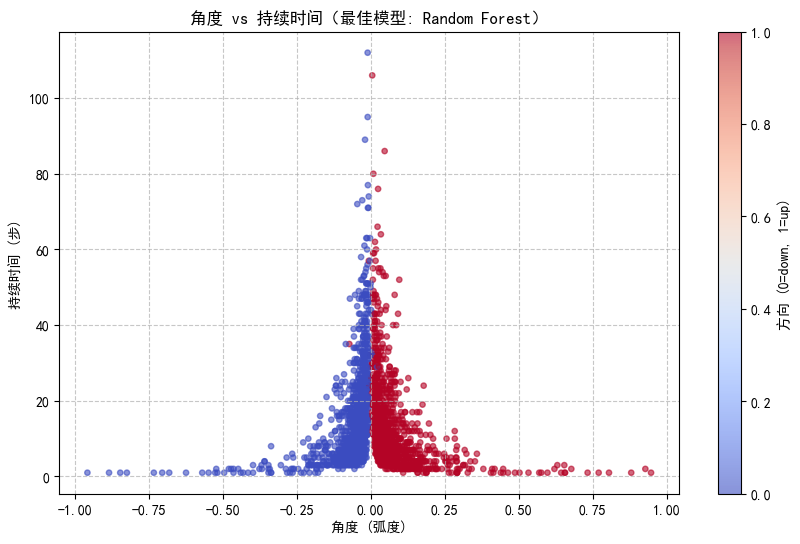

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import os
import warnings
warnings.filterwarnings('ignore')
# ==============================
# 1. 加载数据
# ==============================
df = pd.read_csv(fr"E:\stock\csv_version\000063.SZ_wave_angles.csv")  # ←←← 改成你的 CSV 文件名


# 数据清洗
df = df.dropna(subset=['time_duration', 'angle_radians', 'direction'])
df = df[df['time_duration'] > 0]
df['direction_num'] = df['direction'].map({'up': 1, 'down': 0})

print(f"✅ 加载 {len(df)} 条有效线段")
print("方向分布:\n", df['direction'].value_counts())
print("持续时间统计:\n", df['time_duration'].describe())

# ==============================
# 2. 准备特征和目标
# ==============================
features = ['angle_radians', 'direction_num']
X = df[features]
y = df['time_duration']

# ==============================
# 3. 训练 Random Forest
# ==============================
print("\n=== 训练 Random Forest ===")
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_mae = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')
rf_rmse = np.sqrt(-cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error'))
print(f"MAE: {rf_mae.mean():.2f} ± {rf_mae.std():.2f}")
print(f"RMSE: {rf_rmse.mean():.2f} ± {rf_rmse.std():.2f}")

rf.fit(X, y)

# ==============================
# 4. 训练 XGBoost
# ==============================
print("\n=== 训练 XGBoost ===")
xgb_model = xgb.XGBRegressor(
    max_depth=4,        # 最关键！
    learning_rate=0.1,
    n_estimators=200,   # 用早停的话可设大些（如200），实际会自动停
    subsample=0.8,
    reg_alpha=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_mae = -cross_val_score(xgb_model, X, y, cv=5, scoring='neg_mean_absolute_error')
xgb_rmse = np.sqrt(-cross_val_score(xgb_model, X, y, cv=5, scoring='neg_mean_squared_error'))
print(f"MAE: {xgb_mae.mean():.2f} ± {xgb_mae.std():.2f}")
print(f"RMSE: {xgb_rmse.mean():.2f} ± {xgb_rmse.std():.2f}")

xgb_model.fit(X, y)

# ==============================
# 5. 选择最佳模型
# ==============================
rf_mae_avg = rf_mae.mean()
xgb_mae_avg = xgb_mae.mean()

if rf_mae_avg < xgb_mae_avg:
    best_model = rf
    best_name = "Random Forest"
    best_mae = rf_mae_avg
else:
    best_model = xgb_model
    best_name = "XGBoost"
    best_mae = xgb_mae_avg

print(f"\n🏆 最佳模型: {best_name} (MAE={best_mae:.2f})")

# ==============================
# 6. 特征重要性
# ==============================
if best_name == "Random Forest":
    importances = rf.feature_importances_
else:
    importances = xgb_model.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
print("\n🌳 特征重要性:")
print(feat_imp)

# ==============================
# 7. 预测函数（供你调用）
# ==============================
def predict_remaining_time(angle, direction, observed_duration, model=best_model):
    """
    预测剩余持续时间
    :param angle: 当前线段角度（弧度）
    :param direction: 'up' 或 'down'
    :param observed_duration: 已持续步数
    :param model: 使用的模型（默认最佳）
    :return: 预测剩余步数（整数，≥0）
    """
    dir_num = 1 if direction == 'up' else 0
    total_pred = model.predict([[angle, dir_num]])[0]
    remaining = total_pred - observed_duration
    return max(0, int(round(remaining)))

# ==============================
# 8. 示例预测
# ==============================
print("\n" + "="*50)
print("🔍 示例预测 (剩余时间):")
print("="*50)
examples = [
    (0.2, 'up', 3),
    (0.6, 'up', 2),
    (0.3, 'down', 4),
    (0.1, 'down', 5),
    (0.7, 'up', 1)
]

for angle, direction, obs in examples:
    rem = predict_remaining_time(angle, direction, obs)
    total = obs + rem
    print(f"角度={angle:4.2f}, 方向={direction:4s}, 已持续={obs:2d} → 预测总长≈{total:2d}, 剩余≈{rem}")

# ==============================
# 9. 可视化（角度 vs 持续时间）
# ==============================
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['angle_radians'], df['time_duration'], 
                     c=df['direction_num'], cmap='coolwarm', alpha=0.6, s=15)
plt.xlabel('角度 (弧度)')
plt.ylabel('持续时间 (步)')
plt.title(f'角度 vs 持续时间（最佳模型: {best_name}）')
plt.colorbar(scatter, label='方向 (0=down, 1=up)')
plt.grid(True, linestyle='--', alpha=0.7)

# 保存图形
output_file = 'rf_xgb_analysis.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"\n✅ 图形已保存为: {os.path.abspath(output_file)}")
